   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 8.8 MB/s eta 0:00:00
Running validation experiment with n = 1,000,000 iterations...
Progress: 100,000/1,000,000 iterations
Progress: 200,000/1,000,000 iterations
Progress: 300,000/1,000,000 iterations
Progress: 400,000/1,000,000 iterations
Progress: 500,000/1,000,000 iterations
Progress: 600,000/1,000,000 iterations
Progress: 700,000/1,000,000 iterations
Progress: 800,000/1,000,000 iterations
Progress: 900,000/1,000,000 iterations
Progress: 1,000,000/1,000,000 iterations

--- Statistical Results ---
Brainwallet candidates - Mean Hamming distance: 79.62, Std: 6.02
RNG candidates         - Mean Hamming distance: 80.00, Std: 6.32


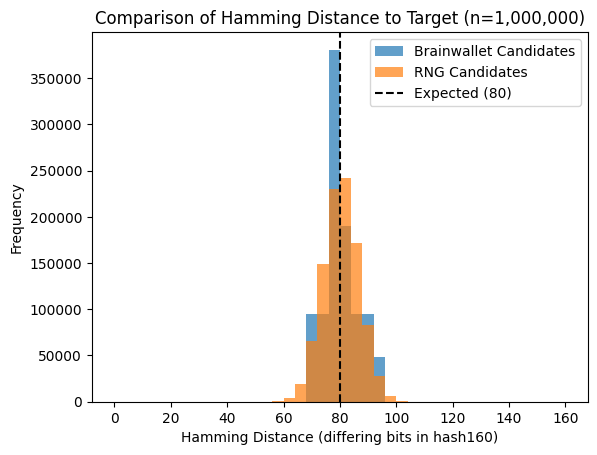

In [1]:
# Install required packages
!pip install pycryptodome ecdsa base58 numpy matplotlib

import hashlib
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import ecdsa
from Crypto.Hash import RIPEMD160
import base58
from statistics import mean, stdev

# -------------------------------
# Configuration & Target Setup
# -------------------------------
TARGET_ADDRESS = "1FeexV6bAHb8ybZjqQMjJrcCrHGW9sb6uF"
TXID = "e67a0550848b79322f4b5e8b2c856ebfb6da9a26f664ca36"

def get_hash160(address: str) -> bytes:
    """
    Extracts the 20-byte hash160 (removing the version byte and checksum)
    from a Base58-encoded Bitcoin address.
    """
    decoded = base58.b58decode(address)
    return decoded[1:-4]

TARGET_HASH160 = get_hash160(TARGET_ADDRESS)

# -------------------------------
# Key Generation Functions
# -------------------------------
def generate_candidate_private_key(timestamp, txid, sep="-") -> bytes:
    """
    Generates a candidate private key by computing SHA-256 on the string:
    "{timestamp}{sep}{txid}"
    """
    seed_str = f"{timestamp}{sep}{txid}"
    return hashlib.sha256(seed_str.encode()).digest()

def generate_brainwallet_key(passphrase: str) -> bytes:
    """
    Generates a brainwallet-style private key from a passphrase using SHA-256.
    """
    return hashlib.sha256(passphrase.encode('utf-8')).digest()

def generate_rng_key() -> bytes:
    """
    Generates a 256-bit private key using os.urandom.
    """
    return os.urandom(32)

def private_key_to_address(privkey_bytes: bytes) -> str:
    """
    Derives the Bitcoin address (Base58) from a given private key using an uncompressed public key.
    """
    sk = ecdsa.SigningKey.from_string(privkey_bytes, curve=ecdsa.SECP256k1)
    vk = sk.verifying_key
    public_key = b'\x04' + vk.to_string()  # uncompressed public key
    sha_hash = hashlib.sha256(public_key).digest()
    ripemd160_hash = RIPEMD160.new(sha_hash).digest()
    versioned_payload = b'\x00' + ripemd160_hash
    checksum = hashlib.sha256(hashlib.sha256(versioned_payload).digest()).digest()[:4]
    binary_address = versioned_payload + checksum
    return base58.b58encode(binary_address).decode()

def compute_hash160(privkey: bytes) -> bytes:
    """
    Computes the hash160 (RIPEMD160 of SHA-256 of the uncompressed public key)
    for a given private key.
    """
    sk = ecdsa.SigningKey.from_string(privkey, curve=ecdsa.SECP256k1)
    vk = sk.verifying_key
    public_key = b'\x04' + vk.to_string()
    sha_hash = hashlib.sha256(public_key).digest()
    return RIPEMD160.new(sha_hash).digest()

def hamming_distance(b1: bytes, b2: bytes) -> int:
    """
    Computes the Hamming distance (number of differing bits) between two byte strings.
    """
    return sum(bin(a ^ b).count("1") for a, b in zip(b1, b2))

# -------------------------------
# Brainwallet Dictionary
# -------------------------------
# A realistic dictionary of common passphrases and passwords.
common_passphrases = [
    "password", "abc123", "iloveyou", "123456", "letmein", "football",
    "monkey", "dragon", "baseball", "trustno1", "sunshine", "princess",
    "qwerty", "welcome", "flower", "peace", "master", "shadow", "whatever",
    "admin", "password1"
]

# -------------------------------
# Experiment: Validate Brainwallet vs RNG Using Target
# -------------------------------
def run_validation_experiment(n: int = 1_000_000):
    """
    For each of n iterations, generate:
      - One brainwallet candidate: derived from a randomly selected passphrase from a dictionary.
      - One RNG candidate: generated with os.urandom.
    Compute the hash160 for each candidate and then the Hamming distance to the TARGET_HASH160.
    Returns two NumPy arrays containing the Hamming distances.
    """
    brain_distances = np.empty(n, dtype=np.uint16)
    rng_distances = np.empty(n, dtype=np.uint16)

    for i in range(n):
        # Brainwallet candidate
        passphrase = random.choice(common_passphrases)
        brain_priv = generate_brainwallet_key(passphrase)
        brain_h160 = compute_hash160(brain_priv)
        brain_distances[i] = hamming_distance(brain_h160, TARGET_HASH160)

        # RNG candidate
        rng_priv = generate_rng_key()
        rng_h160 = compute_hash160(rng_priv)
        rng_distances[i] = hamming_distance(rng_h160, TARGET_HASH160)

        if (i+1) % 100000 == 0:
            print(f"Progress: {(i+1):,}/{n:,} iterations")

    return brain_distances, rng_distances

# -------------------------------
# Main Execution
# -------------------------------
if __name__ == "__main__":
    n = 1_000_000
    print(f"Running validation experiment with n = {n:,} iterations...")
    brain_dists, rng_dists = run_validation_experiment(n)

    # Compute statistics using NumPy
    brain_mean = np.mean(brain_dists)
    brain_std = np.std(brain_dists)
    rng_mean = np.mean(rng_dists)
    rng_std = np.std(rng_dists)

    print("\n--- Statistical Results ---")
    print(f"Brainwallet candidates - Mean Hamming distance: {brain_mean:.2f}, Std: {brain_std:.2f}")
    print(f"RNG candidates         - Mean Hamming distance: {rng_mean:.2f}, Std: {rng_std:.2f}")

    # Plot histograms for visual comparison
    plt.hist(brain_dists, bins=range(0, 161, 4), alpha=0.7, label='Brainwallet Candidates')
    plt.hist(rng_dists, bins=range(0, 161, 4), alpha=0.7, label='RNG Candidates')
    # For a 160-bit hash, expected differences between two random 160-bit values is ~80 bits.
    plt.axvline(x=80, color='k', linestyle='--', label='Expected (80)')
    plt.xlabel("Hamming Distance (differing bits in hash160)")
    plt.ylabel("Frequency")
    plt.title("Comparison of Hamming Distance to Target (n=1,000,000)")
    plt.legend()
    plt.show()
